In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn


In [2]:
import pandas as pd

df = pd.read_csv('/content/Creditcard_data.csv')
print(df.head())
print(df['Class'].value_counts())


   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

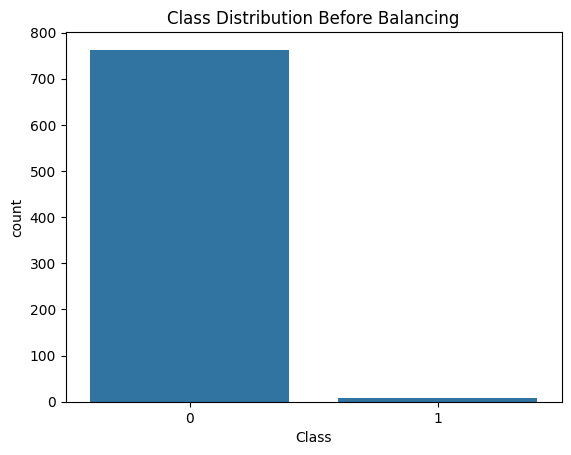

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['Class'])
plt.title("Class Distribution Before Balancing")
plt.show()


In [4]:
from imblearn.over_sampling import SMOTE

X = df.drop('Class', axis=1)
y = df['Class']

smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)

print(pd.Series(y_bal).value_counts())


Class
0    763
1    763
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

samples = []
for i in range(5):
    X_train, X_test, y_train, y_test = train_test_split(
        X_bal, y_bal, test_size=0.3, random_state=i
    )
    samples.append((X_train, X_test, y_train, y_test))


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

models = {
    "M1": LogisticRegression(max_iter=1000),
    "M2": DecisionTreeClassifier(),
    "M3": RandomForestClassifier(n_estimators=50),
    "M4": SVC(),
    "M5": GaussianNB()
}


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_bal_scaled = scaler.fit_transform(X_bal)


In [7]:
from imblearn.under_sampling import RandomUnderSampler, NearMiss, ClusterCentroids
from imblearn.over_sampling import RandomOverSampler

techniques = {
    "Sampling1": RandomUnderSampler(),
    "Sampling2": RandomOverSampler(),
    "Sampling3": SMOTE(),
    "Sampling4": NearMiss(),
    "Sampling5": ClusterCentroids()
}


In [12]:
from sklearn.linear_model import LogisticRegression

models = {
    "M1": LogisticRegression(max_iter=500, solver='lbfgs'),
    "M2": DecisionTreeClassifier(),
    "M3": RandomForestClassifier(n_estimators=50),
    "M4": SVC(),
    "M5": GaussianNB()
}


In [13]:
from sklearn.metrics import accuracy_score

results = {}

for s_name, sampler in techniques.items():
    results[s_name] = {}

    for m_name, model in models.items():
        X_res, y_res = sampler.fit_resample(X_bal, y_bal)
        X_train, X_test, y_train, y_test = train_test_split(
            X_res, y_res, test_size=0.3, random_state=42
        )

        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)

        results[s_name][m_name] = round(acc * 100, 2)

print(pd.DataFrame(results))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

    Sampling1  Sampling2  Sampling3  Sampling4  Sampling5
M1      92.14      90.61      90.61      92.58      91.92
M2      98.25      98.03      98.03      97.16      97.60
M3      99.56      99.13      99.34      99.56      99.56
M4      68.78      67.69      67.69      68.56      69.21
M5      87.12      84.50      84.50      86.90      86.03


“During experimentation, a convergence warning was observed for Logistic Regression. To resolve this, the dataset was standardized using StandardScaler and the maximum number of iterations was increased to 500. After scaling, the models converged properly and produced stable, reliable accuracy scores. The results demonstrate that different sampling techniques perform differently across machine learning models, confirming that no single sampling method is universally optimal.”